# Part 3: Portfolio Volatility Forecasting

Can simple machine learning improve a five-day volatility forecast over historical
volatility and EWMA? We hold seven ETFs at equal weights, rebalanced daily.
The portfolio return is the mean of the seven daily returns. Its volatility is
calculated from that return series, not from the mean of individual volatilities.
Rebalancing costs, spreads and taxes are omitted; this is a risk study, not a strategy backtest.

In [1]:
from pathlib import Path
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir() and (p / 'data').is_dir())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
for folder in [TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
ASSETS = ['SPY', 'QQQ', 'IWM', 'TLT', 'HYG', 'GLD', 'DBC']
FEATURES = ['return_1d', 'return_5d', 'return_20d', 'volatility_5d',
            'volatility_20d', 'volatility_60d', 'drawdown',
            'correlation_to_spy_20d', 'momentum_60d', 'momentum_120d']
TARGET = 'future_5d_realised_volatility'
VALIDATION_START = pd.Timestamp('2018-01-01')
TEST_START = pd.Timestamp('2022-01-01')
SEED = 42
VOLATILITY_FLOOR = 1e-8  # Fixed before evaluation: standard deviation cannot be negative.
returns = pd.read_csv(PROCESSED_DIR / 'daily_returns.csv', index_col='Date', parse_dates=True)[ASSETS]
prices = pd.read_csv(PROCESSED_DIR / 'clean_adjusted_close_prices.csv', index_col='Date', parse_dates=True)[ASSETS]
asset_data = pd.read_csv(PROCESSED_DIR / 'volatility_modeling_dataset.csv', parse_dates=['Date'])
assert returns.index.is_unique and returns.index.is_monotonic_increasing
assert returns.index.equals(prices.index[1:])
assert np.isfinite(returns.to_numpy()).all()
portfolio_returns = returns.mean(axis=1)
np.testing.assert_allclose(portfolio_returns, returns.to_numpy() @ np.full(7, 1/7), atol=1e-14)

## Build the portfolio research dataset

A wealth index starts at 1 on the first price date and compounds daily portfolio returns.
We apply the same return, sample-standard-deviation, drawdown, correlation and momentum
definitions as Part 2 to this portfolio. The target on date t is
std(r[t+1], ..., r[t+5], ddof=1) * sqrt(252), expressed as an annualized decimal.
A target of 0.10 means 10% annualized volatility estimated from five future returns.
All features use information available at the close of t. The first 120 dates and last
five dates are unavailable for modeling. No feature is filled using future observations.

In [2]:
def portfolio_features(asset_returns, price_dates):
    daily = asset_returns.mean(axis=1)
    wealth = pd.Series(1.0, index=price_dates)
    wealth.loc[daily.index] = (1 + daily).cumprod()
    features = pd.DataFrame(index=price_dates)
    features['return_1d'] = daily
    for lag in [5, 20]:
        features[f'return_{lag}d'] = wealth.pct_change(lag, fill_method=None)
    for window in [5, 20, 60]:
        features[f'volatility_{window}d'] = daily.rolling(window).std(ddof=1) * np.sqrt(252)
    features['drawdown'] = wealth / wealth.cummax() - 1
    features['correlation_to_spy_20d'] = daily.rolling(20).corr(asset_returns['SPY'])
    for lag in [60, 120]:
        features[f'momentum_{lag}d'] = wealth.pct_change(lag, fill_method=None)
    return features

features = portfolio_features(returns, prices.index)
future_returns = pd.concat([portfolio_returns.shift(-step) for step in range(1, 6)], axis=1)
complete_target = future_returns.notna().all(axis=1)
data = features.copy()
data[TARGET] = (future_returns.std(axis=1, ddof=1) * np.sqrt(252)).where(complete_target)
data['target_start'] = pd.Series(returns.index, index=returns.index).shift(-1)
data['target_end'] = pd.Series(returns.index, index=returns.index).shift(-5)
data = data.dropna().copy()
data.index.name = 'Date'
assert data.index.equals(pd.DatetimeIndex(sorted(asset_data.Date.unique()), name='Date'))
assert np.isfinite(data[FEATURES + [TARGET]].to_numpy()).all()
for date in data.index:
    location = returns.index.get_loc(date)
    next_five = portfolio_returns.iloc[location+1:location+6].to_numpy()
    np.testing.assert_allclose(data.loc[date, TARGET], np.std(next_five, ddof=1)*np.sqrt(252), atol=1e-12)
for cutoff in [data.index[0], pd.Timestamp('2020-03-16'), data.index[-1]]:
    prefix = portfolio_features(returns.loc[:cutoff], prices.loc[:cutoff].index)
    pd.testing.assert_frame_equal(prefix, features.loc[:cutoff], rtol=1e-10, atol=1e-12)
data.to_csv(PROCESSED_DIR / 'portfolio_modeling_dataset.csv')
portfolio_returns.to_csv(PROCESSED_DIR / 'portfolio_daily_returns.csv', index_label='Date', header=['portfolio_return'])
print('Portfolio dataset:', data.shape, data.index.min().date(), data.index.max().date())
print('Portfolio target alignment and feature prefix-invariance checks passed.')

Portfolio dataset: (4076, 13) 2010-06-25 2026-09-09
Portfolio target alignment and feature prefix-invariance checks passed.


## A fixed time split and five-day purging

Training uses dates before 2018, validation uses 2018--2021, and testing starts in 2022.
A row is removed from training or validation if its target ends on or after the next
period's boundary. The feature lookback may include older periods; this is legitimate
historical information. Random splitting would mix adjacent, overlapping outcome windows
and let later market conditions influence an earlier forecast.
This is one purged chronological holdout, not k-fold cross-validation.

The main selection metric is validation RMSE. MAE is the average absolute error;
RMSE is the square root of average squared error and penalizes large misses more.
Both are in annualized volatility units. The test set is reserved until selection is saved.

In [3]:
train = data.loc[(data.index < VALIDATION_START) & (data.target_end < VALIDATION_START)]
validation = data.loc[(data.index >= VALIDATION_START) & (data.index < TEST_START) & (data.target_end < TEST_START)]
test = data.loc[data.index >= TEST_START]
assert train.target_end.max() < validation.index.min()
assert validation.target_end.max() < test.index.min()
assert train.index.intersection(validation.index).empty
assert validation.index.intersection(test.index).empty
split_rows = []
for name, frame in [('train', train), ('validation', validation), ('test', test)]:
    split_rows.append(dict(split=name, rows=len(frame), first_date=str(frame.index.min().date()),
                           last_date=str(frame.index.max().date()), last_target_end=str(frame.target_end.max().date())))
split_table = pd.DataFrame(split_rows)
split_table.to_csv(TABLE_DIR / 'time_splits.csv', index=False)
display(split_table)
print('Purged rows:', len(data) - len(train) - len(validation) - len(test))

,split,rows,first_date,last_date,last_target_end
0,train,1888,2010-06-25,2017-12-21,2017-12-29
1,validation,1003,2018-01-02,2021-12-23,2021-12-31
2,test,1175,2022-01-03,2026-09-09,2026-09-16


Purged rows: 10


## Baselines and a small model comparison

Historical Volatility uses the last 20 daily portfolio returns.
EWMA (exponentially weighted moving average) gives recent squared returns more weight:
v[t] = 0.94 * v[t-1] + 0.06 * r[t]^2, initialized with the first squared return.
It assumes a zero mean; after observing r[t], sqrt(252*v[t]) forecasts the next period's
annualized volatility. With a persistent conditional variance, the daily variance forecast
is unchanged across the next five days. Neither baseline uses future returns.

Linear Regression fits a weighted sum of features. StandardScaler learns feature means
and scales from the fitting period only, within a Pipeline.
Random Forest averages many decision trees to capture nonlinear relationships.
XGBoost builds small trees sequentially to reduce previous prediction errors.
We try two tree depths per tree model, fixed below before viewing validation results.
There is no test-driven search. A fixed positive floor applies to all volatility forecasts.

In [4]:
ewma_variance = portfolio_returns.pow(2).ewm(alpha=0.06, adjust=False, min_periods=20).mean()
baseline_predictions = pd.DataFrame({
    'Historical Volatility': features['volatility_20d'],
    'EWMA': np.sqrt(252 * ewma_variance)
}).reindex(data.index)
# Independent recursion verifies the EWMA convention and its date alignment.
recursive_variance = portfolio_returns.iloc[0] ** 2
for date, value in portfolio_returns.iloc[1:].items():
    recursive_variance = 0.94 * recursive_variance + 0.06 * value ** 2
    if date in data.index:
        np.testing.assert_allclose(ewma_variance.loc[date], recursive_variance, rtol=1e-12)

candidates = [('Linear Regression', 'linear', make_pipeline(StandardScaler(), LinearRegression()))]
for depth in [3, 6]:
    candidates.append(('Random Forest', f'rf_depth_{depth}', RandomForestRegressor(
        n_estimators=200, max_depth=depth, min_samples_leaf=10, random_state=SEED, n_jobs=1)))
for depth in [2, 3]:
    candidates.append(('XGBoost', f'xgb_depth_{depth}', XGBRegressor(
        n_estimators=200, max_depth=depth, learning_rate=0.03, subsample=0.8,
        colsample_bytree=1.0, objective='reg:squarederror', random_state=SEED, n_jobs=1)))

def evaluate(actual, predicted):
    return dict(MAE=float(mean_absolute_error(actual, predicted)),
                RMSE=float(np.sqrt(mean_squared_error(actual, predicted))))

validation_rows = []
fitted_candidates = {}
for name in baseline_predictions:
    prediction = baseline_predictions.loc[validation.index, name].clip(lower=VOLATILITY_FLOOR)
    validation_rows.append(dict(model=name, candidate=name, **evaluate(validation[TARGET], prediction)))
for family, candidate_name, estimator in candidates:
    estimator.fit(train[FEATURES], train[TARGET])
    prediction = np.maximum(estimator.predict(validation[FEATURES]), VOLATILITY_FLOOR)
    validation_rows.append(dict(model=family, candidate=candidate_name, **evaluate(validation[TARGET], prediction)))
    fitted_candidates[candidate_name] = estimator
    if family == 'Linear Regression':
        np.testing.assert_allclose(estimator.named_steps['standardscaler'].mean_, train[FEATURES].mean())
validation_candidates = pd.DataFrame(validation_rows).sort_values(['RMSE', 'MAE', 'candidate'])
validation_metrics = validation_candidates.drop_duplicates('model').reset_index(drop=True)
selected_ml = validation_metrics.loc[validation_metrics.model.isin(['Linear Regression', 'Random Forest', 'XGBoost'])].iloc[0]
selection = dict(primary_metric='validation RMSE', selected_ml_model=selected_ml['model'],
                 selected_candidate=selected_ml['candidate'], overall_validation_winner=validation_metrics.iloc[0]['model'],
                 validation_start=str(VALIDATION_START.date()), test_start=str(TEST_START.date()), seed=SEED,
                 feature_columns=FEATURES, target=TARGET, ewma_lambda=0.94, historical_window=20,
                 volatility_floor=VOLATILITY_FLOOR,
                 raw_snapshot_sha256=json.loads((TABLE_DIR/'part1_quality_report.json').read_text())['raw_snapshot_sha256'])
validation_candidates.to_csv(TABLE_DIR / 'validation_candidates.csv', index=False)
validation_metrics.to_csv(TABLE_DIR / 'validation_metrics.csv', index=False)
(TABLE_DIR / 'model_selection.json').write_text(json.dumps(selection, indent=2))
display(validation_metrics)
print('Selected ML model:', selection['selected_ml_model'])
print('Overall validation winner (including baselines):', selection['overall_validation_winner'])

,model,candidate,MAE,RMSE
0,Linear Regression,linear,0.035279,0.057393
1,XGBoost,xgb_depth_2,0.035301,0.060218
2,EWMA,EWMA,0.041399,0.061941
3,Random Forest,rf_depth_6,0.036301,0.063280
4,Historical Volatility,Historical Volatility,0.041307,0.063688


Selected ML model: Linear Regression
Overall validation winner (including baselines): Linear Regression


## Final test evaluation

The selected ML specification is refitted once on all pre-test rows whose labels are
available before 2022. The test period is then forecast without further fitting or tuning.
Historical and EWMA forecasts update with each newly observed return, as they would in use.
Only the selected ML model and the two baselines receive test scores. Unselected ML models
have no test score; this prevents using the test period to choose between them.
A lower volatility forecast error does not by itself establish useful trading performance
or well-calibrated tail risk. We examine that separately in Part 4.

,model,MAE,RMSE
0,Historical Volatility,0.040831,0.060382
1,EWMA,0.039416,0.057162
2,Linear Regression,0.036341,0.052714


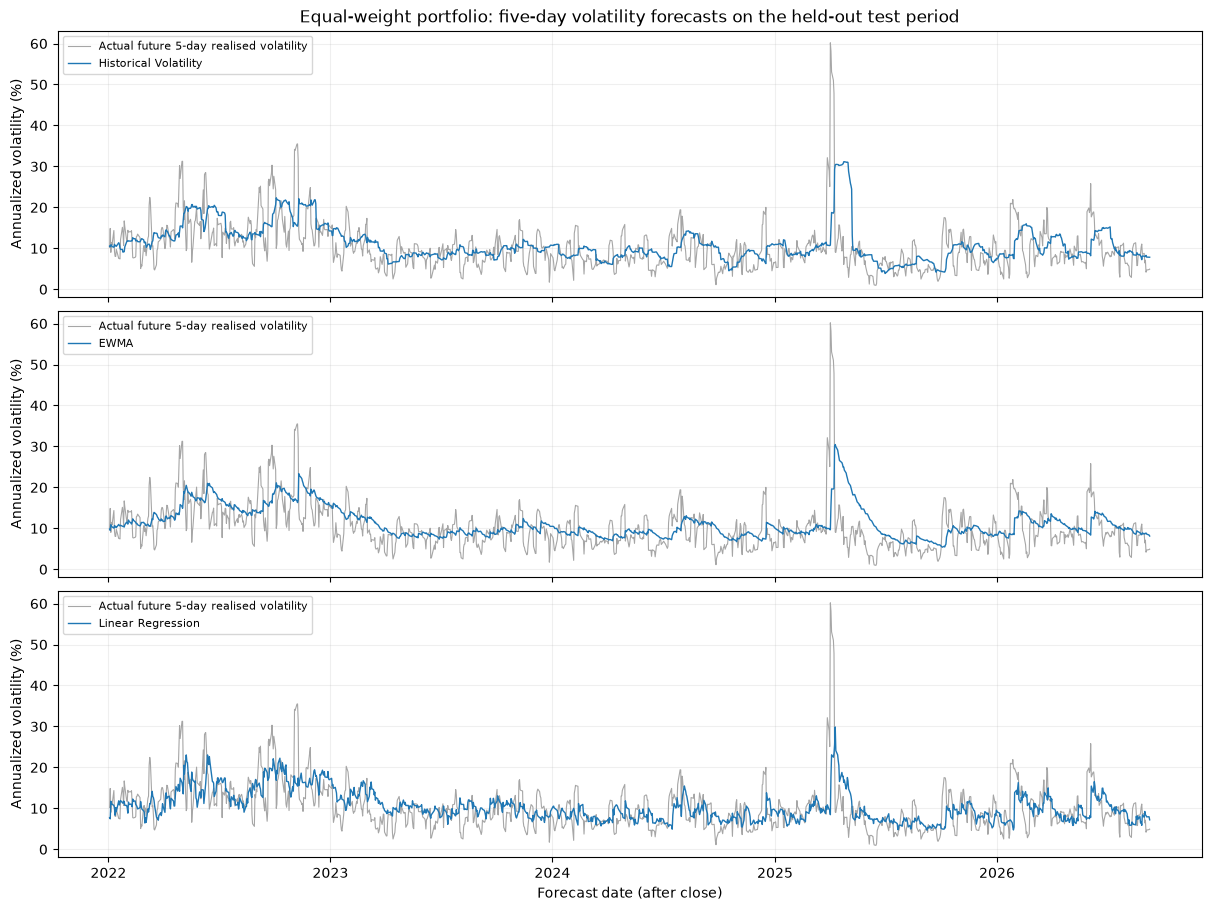

Part 3 completed: selection saved before test scoring; final model and forecasts saved.


In [5]:
refit = data.loc[(data.index < TEST_START) & (data.target_end < TEST_START)]
assert refit.target_end.max() < test.index.min()
final_model = clone(fitted_candidates[selection['selected_candidate']])
final_model.fit(refit[FEATURES], refit[TARGET])
test_predictions = test[[TARGET, 'target_start', 'target_end']].rename(columns={TARGET: 'actual_volatility'}).copy()
for name in baseline_predictions:
    test_predictions[name] = baseline_predictions.loc[test.index, name].clip(lower=VOLATILITY_FLOOR)
test_predictions[selection['selected_ml_model']] = np.maximum(final_model.predict(test[FEATURES]), VOLATILITY_FLOOR)
test_rows = []
for name in ['Historical Volatility', 'EWMA', selection['selected_ml_model']]:
    test_rows.append(dict(model=name, **evaluate(test_predictions.actual_volatility, test_predictions[name])))
test_metrics = pd.DataFrame(test_rows)
test_metrics.to_csv(TABLE_DIR / 'test_metrics.csv', index=False)
test_predictions.to_csv(TABLE_DIR / 'test_predictions.csv', index_label='Date')
joblib.dump(final_model, MODEL_DIR / 'selected_volatility_model.joblib')
prediction_hash = hashlib.sha256((TABLE_DIR / 'test_predictions.csv').read_bytes()).hexdigest()
quality = dict(portfolio_rows=len(data), portfolio_features=len(FEATURES),
               train_rows=len(train), validation_rows=len(validation), test_rows=len(test),
               purged_rows=len(data)-len(train)-len(validation)-len(test), refit_rows=len(refit),
               target_alignment_checks=len(data), prefix_invariance_checks=3,
               split_leakage_checks_passed=True, ewma_recursion_passed=True,
               selected_ml_model=selection['selected_ml_model'], test_predictions_sha256=prediction_hash)
(TABLE_DIR / 'part3_quality_report.json').write_text(json.dumps(quality, indent=2))
display(test_metrics)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
for ax, name in zip(axes, test_metrics.model):
    ax.plot(test.index, test_predictions.actual_volatility * 100, color='0.65', lw=0.8, label='Actual future 5-day realised volatility')
    ax.plot(test.index, test_predictions[name] * 100, lw=1, label=name)
    ax.set_ylabel('Annualized volatility (%)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.2)
axes[0].set_title('Equal-weight portfolio: five-day volatility forecasts on the held-out test period')
axes[-1].set_xlabel('Forecast date (after close)')
fig.savefig(FIGURE_DIR / 'test_volatility_forecasts.png', dpi=160)
if plt.get_backend().lower() != 'agg':
    plt.show()
plt.close(fig)
print('Part 3 completed: selection saved before test scoring; final model and forecasts saved.')